In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("data/raw/df.csv")
df.head(2)

,user_id,date,dow,post,exposed,treated_group,discount_pct,region,device_type,traffic_source,...,gross_sales_pre_discount,net_revenue,unit_cost,total_cost,margin_dollars,margin_rate,counterfactual_units,counterfactual_revenue,counterfactual_margin_dollars,ever_exposed
0,0,2025-11-01,5,0,0,0,0.0,South,Desktop,Email,...,16.856929,16.856929,11.017525,11.017525,5.839403,0.34641,1,16.856929,5.839403,1
1,0,2025-11-02,6,0,0,0,0.0,South,Desktop,Email,...,33.713857,33.713857,11.017525,22.035051,11.678807,0.34641,2,33.713857,11.678807,1


### 1. Create Event Time  

We need a variable that measures:  

        Days relative to promo start  

Assume promo starts when post == 1 first appears  

Define event time = 0 on first promo day.

In [3]:
# identify promo start date
promo_start = df.loc[df['post']==1, 'date'].min() 

# create event time in days  
df['event_time'] = (pd.to_datetime(df['date']) - pd.to_datetime(promo_start)).dt.days

Now:  

	• event_time = 0 → promo starts
	• event_time < 0 → pre-period
	• event_time > 0 → post-period

### 2. Create Event Dummies (Exclude One Pre-Period)  

Create indicators for each event time interacted with treatment.  

Important: We omit one pre-period (usually -1) as baseline

In [4]:
reference_period = -1

def event_col_name(t: int) -> str:
    if t < 0:
        return f"event_m{abs(t)}"
    elif t > 0:
        return f"event_p{t}"
    else:
        return "event_0"

# Create event-treatment indicators with safe names
for t in sorted(df["event_time"].unique()):
    if t == reference_period:
        continue
    df[event_col_name(t)] = ((df["event_time"] == t) & (df["ever_exposed"] == 1)).astype(int)

In [ ]:
df.tail()

### 3. Build Regression Formula  

Include:  

    - all event dummies (except reference)  
    - date fixed effects  
    - user fixed effects  
    - cluster by user  

Using within-transformation approach is cleaner

In [5]:
df.columns

Index(['user_id', 'date', 'dow', 'post', 'exposed', 'treated_group',
       'discount_pct', 'region', 'device_type', 'traffic_source',
       'customer_segment', 'tenure_days', 'prior_30d_spend',
       'engagement_score', 'seasonality_effect', 'baseline_units',
       'true_treatment_effect', 'units', 'list_price',
       'gross_sales_pre_discount', 'net_revenue', 'unit_cost', 'total_cost',
       'margin_dollars', 'margin_rate', 'counterfactual_units',
       'counterfactual_revenue', 'counterfactual_margin_dollars',
       'ever_exposed', 'event_time', 'event_m30', 'event_m29', 'event_m28',
       'event_m27', 'event_m26', 'event_m25', 'event_m24', 'event_m23',
       'event_m22', 'event_m21', 'event_m20', 'event_m19', 'event_m18',
       'event_m17', 'event_m16', 'event_m15', 'event_m14', 'event_m13',
       'event_m12', 'event_m11', 'event_m10', 'event_m9', 'event_m8',
       'event_m7', 'event_m6', 'event_m5', 'event_m4', 'event_m3', 'event_m2',
       'event_0', 'event_p1', 'eve

In [6]:
[c for c in df.columns if c.startswith("event_")][:10]

['event_time',
 'event_m30',
 'event_m29',
 'event_m28',
 'event_m27',
 'event_m26',
 'event_m25',
 'event_m24',
 'event_m23',
 'event_m22']

In [7]:
reference = "event_m1"

event_cols = [c for c in df.columns 
              if c.startswith("event_") 
              and c != reference]

In [8]:
import statsmodels.formula.api as smf

formula = "margin_dollars ~ " + " + ".join(event_cols) + " + C(date)"

model_event = smf.ols(
    formula,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]}
)

print(model_event.summary())

                            OLS Regression Results                            
Dep. Variable:         margin_dollars   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                 1.602e-13
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               1.00
Time:                        17:48:25   Log-Likelihood:            -1.2384e+06
No. Observations:              350000   AIC:                         2.477e+06
Df Residuals:                  349931   BIC:                         2.478e+06
Df Model:                          68                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.207e+

/Users/scottbelarmino/ds_portfolio/project_1_promo_causal_inference/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 69, but rank is 27
  warnings.warn('covariance of constraints does not have full '
/Users/scottbelarmino/ds_portfolio/project_1_promo_causal_inference/.venv/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


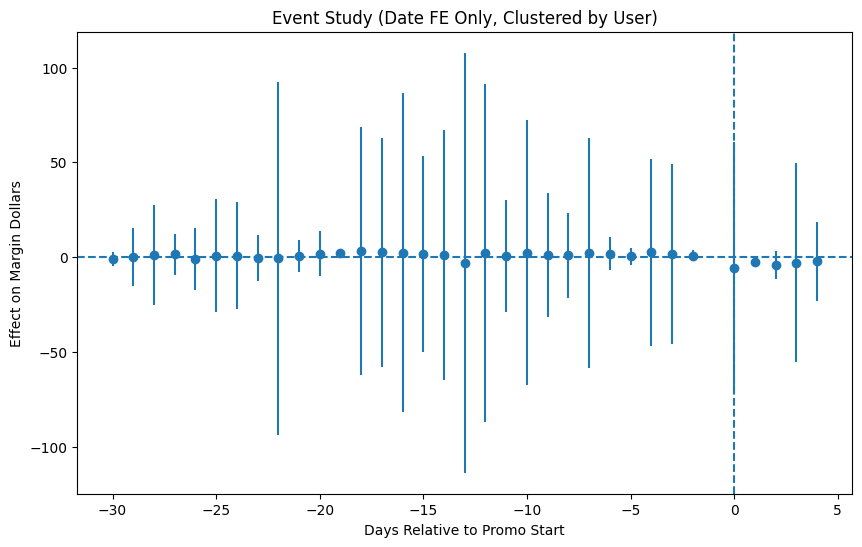

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def col_to_t(col):
    if col == "event_0":
        return 0
    if "_m" in col:
        return -int(col.split("_m")[1])
    if "_p" in col:
        return int(col.split("_p")[1])
    return np.nan

rows = []
for c in event_cols:
    rows.append((col_to_t(c), model_event.params[c], model_event.bse[c]))

event_df = pd.DataFrame(rows, columns=["event_time", "coef", "se"]).sort_values("event_time")

plt.figure(figsize=(10,6))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.errorbar(event_df["event_time"], event_df["coef"], yerr=1.96*event_df["se"], fmt="o")
plt.title("Event Study (Date FE Only, Clustered by User)")
plt.xlabel("Days Relative to Promo Start")
plt.ylabel("Effect on Margin Dollars")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# Build event_time if missing
if "event_time" not in df.columns:
    promo_start = df.loc[df["post"] == 1, "date"].min()
    df["event_time"] = (df["date"] - promo_start).dt.days

# Build ever_exposed if missing
if "ever_exposed" not in df.columns:
    promo = df[df["post"] == 1]
    treated_users = promo.loc[promo["exposed"] == 1, "user_id"].unique()
    df["ever_exposed"] = df["user_id"].isin(treated_users).astype(int)

# Bin event window to [-14, +14] (adjust if you want)
df["event_time_binned"] = df["event_time"].clip(-14, 14)

# Choose reference period (omit -1)
ref = -1

# Create event-time dummies interacted with treated
# These are the coefficients you will plot.
for t in sorted(df["event_time_binned"].unique()):
    if t == ref:
        continue
    df[f"evt_{t}"] = ((df["event_time_binned"] == t) & (df["ever_exposed"] == 1)).astype(int)

In [11]:
# Panel index (entity=user, time=date)
dfp = df.set_index(["user_id", "date"]).sort_index()

evt_cols = [c for c in dfp.columns if c.startswith("evt_")]
y = dfp["margin_dollars"]
X = dfp[evt_cols]

# Event study with two-way fixed effects
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)

# Cluster SEs by user (entity)
res = mod.fit(cov_type="clustered", cluster_entity=True)

print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         margin_dollars   R-squared:                        0.0002
Estimator:                   PanelOLS   R-squared (Between):             -0.7964
No. Observations:              350000   R-squared (Within):               0.0075
Date:                Mon, Mar 02 2026   R-squared (Overall):             -0.2063
Time:                        17:55:13   Log-likelihood                -1.217e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.5583
Entities:                       10000   P-value                           0.0000
Avg Obs:                       35.000   Distribution:               F(18,339948)
Min Obs:                       35.000                                           
Max Obs:                       35.000   F-statistic (robust):             6.0046
                            

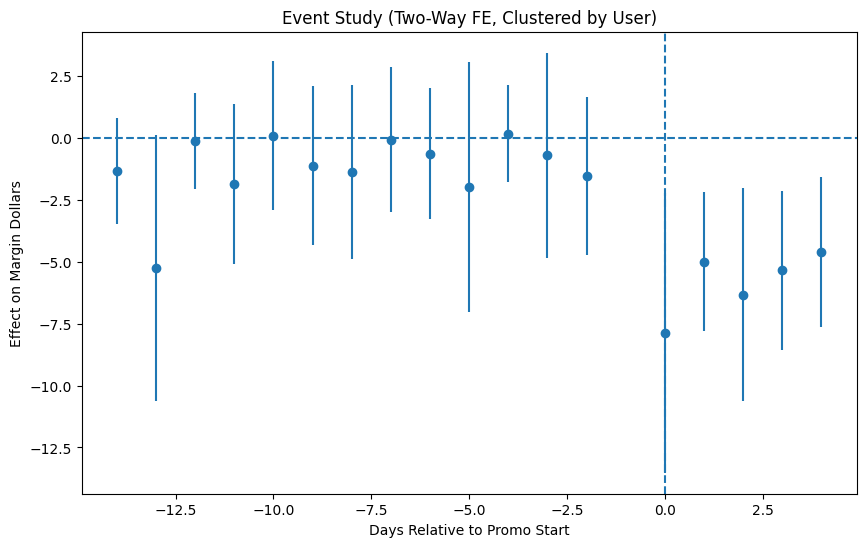

In [12]:
import matplotlib.pyplot as plt

rows = []
for c in evt_cols:
    t = int(c.split("_")[1])  # evt_-5 -> -5, evt_3 -> 3
    rows.append((t, res.params[c], res.std_errors[c]))

event_df = pd.DataFrame(rows, columns=["event_time", "coef", "se"]).sort_values("event_time")

plt.figure(figsize=(10,6))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.errorbar(event_df["event_time"], event_df["coef"], yerr=1.96*event_df["se"], fmt="o")
plt.title("Event Study (Two-Way FE, Clustered by User)")
plt.xlabel("Days Relative to Promo Start")
plt.ylabel("Effect on Margin Dollars")
plt.show()

In [13]:
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         margin_dollars   R-squared:                        0.0002
Estimator:                   PanelOLS   R-squared (Between):             -0.7964
No. Observations:              350000   R-squared (Within):               0.0075
Date:                Mon, Mar 02 2026   R-squared (Overall):             -0.2063
Time:                        17:55:13   Log-likelihood                -1.217e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.5583
Entities:                       10000   P-value                           0.0000
Avg Obs:                       35.000   Distribution:               F(18,339948)
Min Obs:                       35.000                                           
Max Obs:                       35.000   F-statistic (robust):             6.0046
                            

In [14]:
print(res.params.to_string())

evt_-14   -1.335743
evt_-13   -5.258302
evt_-12   -0.130529
evt_-11   -1.846480
evt_-10    0.091691
evt_-9    -1.113654
evt_-8    -1.375083
evt_-7    -0.065623
evt_-6    -0.632730
evt_-5    -1.965826
evt_-4     0.177083
evt_-3    -0.704635
evt_-2    -1.546421
evt_0     -7.873553
evt_1     -4.993065
evt_2     -6.334251
evt_3     -5.345015
evt_4     -4.612625


In [15]:
print(res.pvalues.to_string())

evt_-14    0.217885
evt_-13    0.054661
evt_-12    0.895350
evt_-11    0.263545
evt_-10    0.952554
evt_-9     0.495475
evt_-8     0.444631
evt_-7     0.964912
evt_-6     0.640307
evt_-5     0.444832
evt_-4     0.859204
evt_-3     0.739059
evt_-2     0.342649
evt_0      0.006265
evt_1      0.000516
evt_2      0.003832
evt_3      0.001111
evt_4      0.002941


In [16]:
results_df = pd.DataFrame({
    "coef": res.params,
    "std_err": res.std_errors,
    "p_value": res.pvalues
})

print(results_df.to_string())

             coef   std_err   p_value
evt_-14 -1.335743  1.084054  0.217885
evt_-13 -5.258302  2.736459  0.054661
evt_-12 -0.130529  0.992332  0.895350
evt_-11 -1.846480  1.651514  0.263545
evt_-10  0.091691  1.541018  0.952554
evt_-9  -1.113654  1.633816  0.495475
evt_-8  -1.375083  1.798909  0.444631
evt_-7  -0.065623  1.491756  0.964912
evt_-6  -0.632730  1.354100  0.640307
evt_-5  -1.965826  2.572867  0.444832
evt_-4   0.177083  0.998283  0.859204
evt_-3  -0.704635  2.115390  0.739059
evt_-2  -1.546421  1.629621  0.342649
evt_0   -7.873553  2.880310  0.006265
evt_1   -4.993065  1.437906  0.000516
evt_2   -6.334251  2.190476  0.003832
evt_3   -5.345015  1.639190  0.001111
evt_4   -4.612625  1.551060  0.002941
